# Plot specific proteins in BMIF and Plasma 

In [1]:
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  library(data.table)
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(reshape2)
  library(ggpubr)
})


source("../utilities/functions/helper_functions_olink.R")

In [2]:
bm <- readRDS('../../data/figure-inputs/olink/MM_BMIF_Olink_Final.rds')
plasma <- readRDS('../../data/figure-inputs/olink/MM_Plasma_Olink_Final.rds')
plasma <- plasma[cohort.cohortGuid=='FH1']

In [3]:
tp_color_map <- c(
  'PreTx'    = '#8B0000',
  'PI2C'     = '#C20272',
  'EI'       = '#7502C2',
  'ASCT60d'  = '#0021B0',
  'ASCT90d'  = '#2346DE',
  'ASCT1y'   = '#038AFF',
  'ASCT2y'   = '#008080',
  'Healthy'  = '#00470D'
)

# plotting function
make_protein_plot <- function(df, protlist, times, title, ncol = NULL) {
  plot_df <- df[olink.assay %in% protlist & sample.visitDetails %in% times]
  
  p <- ggplot(
    plot_df,
    aes(x = sample.visitDetails, y = olink.NPX_norm,
        group = subject.subjectGuid, fill = sample.visitDetails)
  ) +
    geom_line(alpha = 0.4) +
    geom_violin(aes(group = sample.visitDetails), alpha = 0.5, scale = "width") +
    geom_point(aes(color = sample.visitDetails), alpha = 0.7, size = 1.5) +
    facet_wrap(~olink.assay, scales = "free_y",
               ncol = if (!is.null(ncol)) ncol else length(protlist)) +
    scale_fill_manual(values = tp_color_map) +
    scale_color_manual(values = tp_color_map) +
    theme_classic(base_size = 20) +
    theme(
      axis.text.x = element_text(size = 20, angle = 45, hjust = 1),
      axis.text.y = element_text(size = 20),
      axis.title.y = element_text(size = 20),
      strip.text = element_text(size = 20, hjust = 0, face = "bold"),
      strip.background = element_blank(),
      legend.position = "none",
      plot.title = element_text(face = "bold", size = 18)
    ) +
    labs(x = "", y = "Olink NPX") +
    ggtitle(title)
  
  return(p)
}

In [4]:
### Extract plasma expression data
plasma_exp <- plasma[,c('olink.assay', 'olink.NPX_norm','subject.subjectGuid','sample.visitDetails', 'sample.sampleKitGuid')]
plasma_exp$Tissue <- 'Plasma'

### Extract bm expression data
bm_exp <- bm[,c('olink.assay', 'olink.NPX_norm','subject.subjectGuid','sample.visitDetails', 'SampleKitGuid')]
bm_exp$Tissue <- 'Bone Marrow'
colnames(bm_exp) <- colnames(plasma_exp)

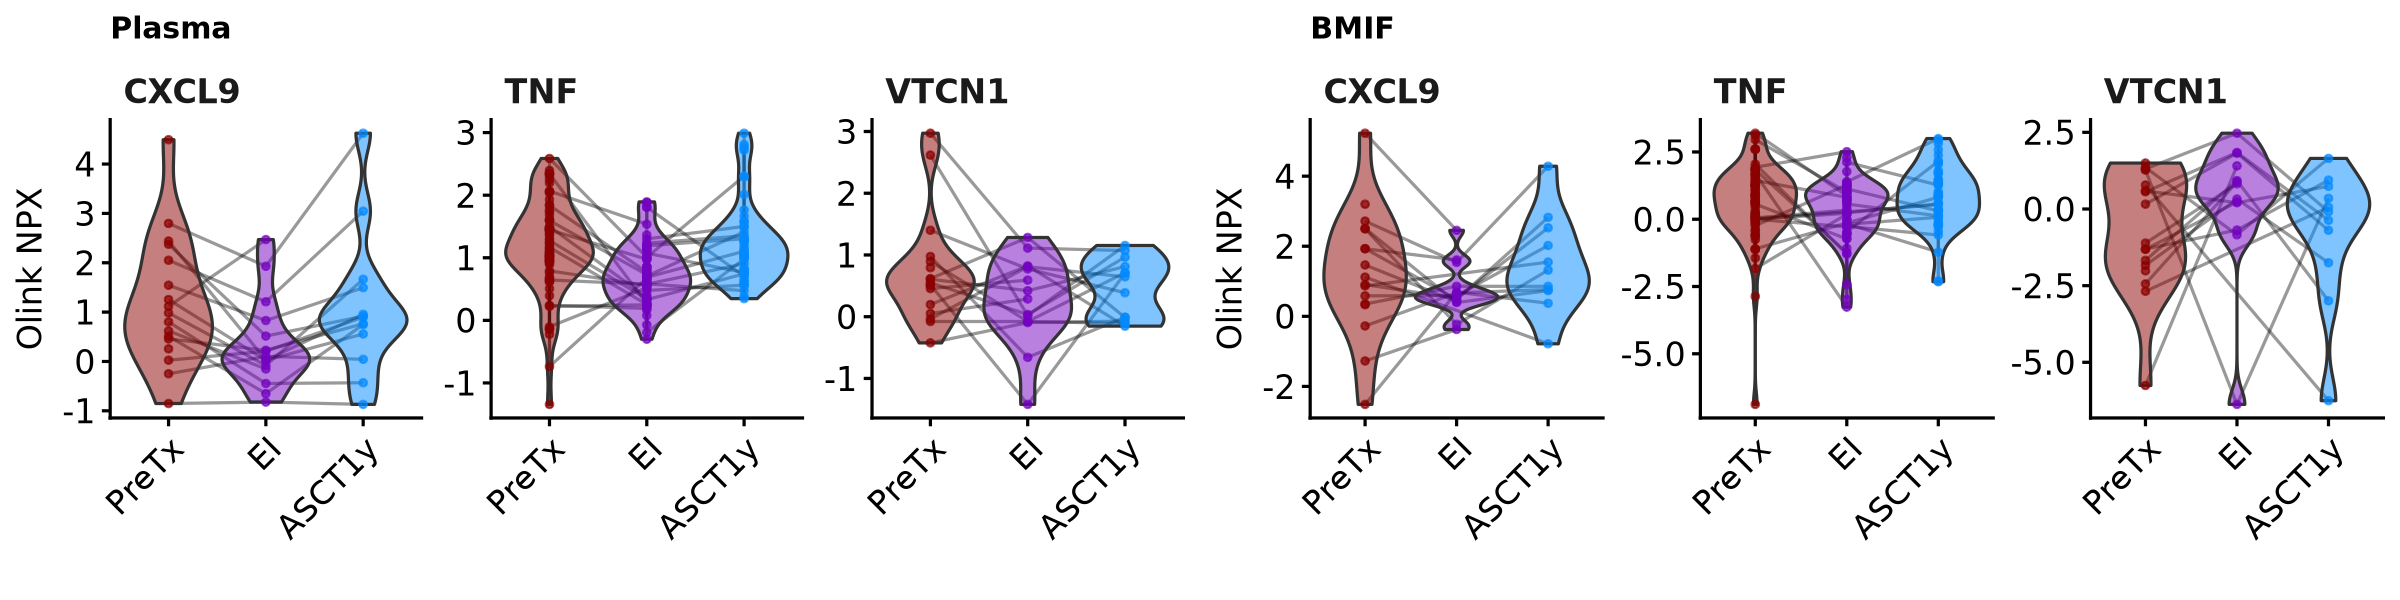

In [5]:
# plot_proteins_color_coded
plot_proteins_color_coded <- function(protlist, times = c('PreTx', 'EI', 'ASCT1y'), ncol = 4) {
  plasma_plot <- make_protein_plot(plasma_exp, protlist, times, "Plasma", ncol = ncol)
  bm_plot     <- make_protein_plot(bm, protlist, times, "BMIF", ncol = ncol)
  ggarrange(plasma_plot, bm_plot, nrow = 1)
}

options(repr.plot.width = 20, repr.plot.height = 5)
protlist <- c('TNF', 'CXCL9', 'VTCN1')
p <- plot_proteins_color_coded(protlist)
p

ggsave("../../data/figure-outputs/supplementary-5/sup_5m.pdf", plot = p, width = 20, height = 5, dpi = 200, device = cairo_pdf)